In [2]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson

%load_ext autoreload
%autoreload 2
%matplotlib inline



In [3]:
pp = Preprocessor()

In [4]:

df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [5]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [6]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data)
X, durations, events , scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 22
count    22.000000
mean      1.909091
std       6.625413
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      30.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 22


In [7]:
surival_data_set  =SurvivalDataSet(X, durations, events)
surival_data_set[0]

(tensor([ 0.2534,  0.9265,  0.7406,  0.5355, -0.5540,  0.4630,  0.2702, -0.7349,
          0.6199,  0.1077,  0.7869,  0.5109,  0.6553,  0.4475,  0.7873,  0.4932,
          0.1719, -0.0138, -0.0278]),
 tensor(43.4000),
 tensor(0.))

In [8]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

Neural Net

In [20]:
in_features = train_X.shape[1]
num_nodes = [16, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

Training the Model

In [21]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

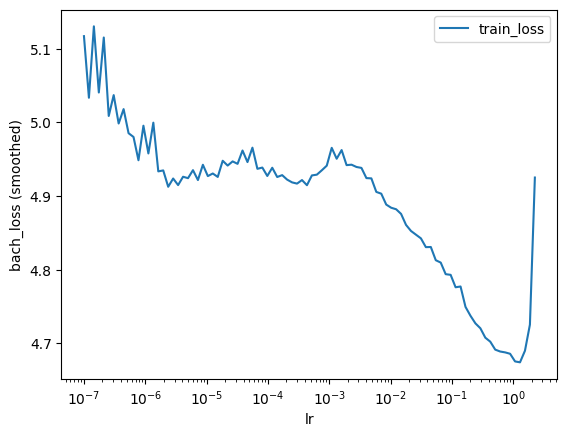

In [22]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=10)

_ = lrfinder.plot()

In [23]:
learning_rate = lrfinder.get_best_lr()
learning_rate

0.12915496650148922

In [24]:
model.optimizer.set_lr(0.01)

In [25]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [26]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9112,	val_loss: 3.1924
1:	[0s / 0s],		train_loss: 4.9424,	val_loss: 3.1316
2:	[0s / 0s],		train_loss: 4.7914,	val_loss: 3.0855
3:	[0s / 0s],		train_loss: 4.4506,	val_loss: 3.0398
4:	[0s / 0s],		train_loss: 4.5857,	val_loss: 3.0130
5:	[0s / 0s],		train_loss: 4.4675,	val_loss: 3.0058
6:	[0s / 0s],		train_loss: 4.4678,	val_loss: 3.0044
7:	[0s / 0s],		train_loss: 4.5740,	val_loss: 3.0085
8:	[0s / 0s],		train_loss: 4.5417,	val_loss: 3.0165
9:	[0s / 0s],		train_loss: 4.4573,	val_loss: 3.0281
10:	[0s / 0s],		train_loss: 4.4418,	val_loss: 3.0345
11:	[0s / 0s],		train_loss: 4.2696,	val_loss: 3.0370
12:	[0s / 0s],		train_loss: 4.3244,	val_loss: 3.0388
13:	[0s / 0s],		train_loss: 4.4252,	val_loss: 3.0316
14:	[0s / 0s],		train_loss: 4.4333,	val_loss: 3.0185
15:	[0s / 0s],		train_loss: 4.4388,	val_loss: 3.0046
16:	[0s / 0s],		train_loss: 4.3200,	val_loss: 2.9837
17:	[0s / 0s],		train_loss: 4.1273,	val_loss: 2.9600
18:	[0s / 0s],		train_loss: 4.1985,	val_loss: 2.9386
19:

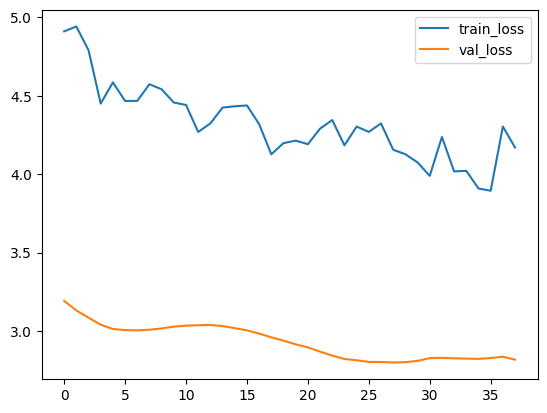

In [27]:
_ = log.plot()

In [28]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()

-2.799448

In [29]:
log.to_pandas().val_loss.idxmin()

27

Prediction

In [30]:
_ = model.compute_baseline_hazards()

In [31]:
surv = model.predict_surv_df(input=test_X)

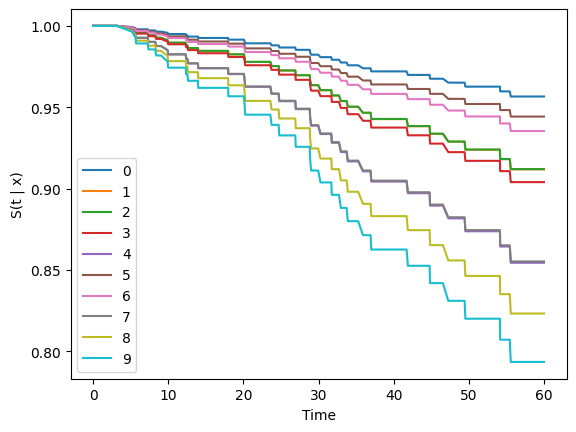

In [32]:
surv.iloc[:, :10].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

Evaluation

In [33]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [34]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [35]:
ev.concordance_td()

0.5277777777777778

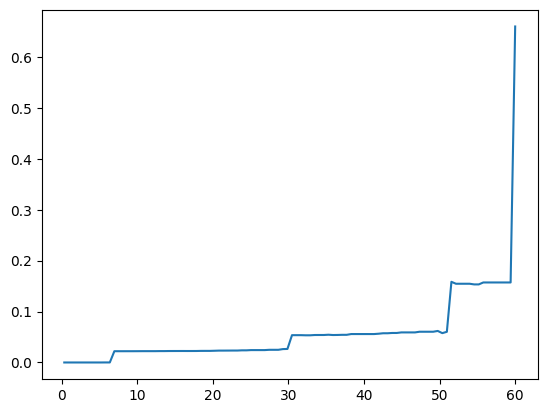

In [36]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [37]:
ev.integrated_brier_score(time_grid=time_grid)

0.05424519405365571

In [38]:
ev.integrated_nbll(time_grid)

0.2062621411483544